<a href="https://colab.research.google.com/github/khoirulsr/AI_Engineer/blob/main/Copy_of_Latihan_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset bisa Download disini :

https://www.kaggle.com/datasets/radheshyamkollipara/bank-customer-churn


Gunakan column "Exited" sebagai target variable


# Import semua Library

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(color_codes=True)
pd.set_option('display.max_columns', None)

# Import Dataset

In [ ]:
df = pd.read_csv('Customer-Churn-Records.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


# Exploratory Data Analysis

In [ ]:
for col in df.select_dtypes(include='object'):
    print(f'{col}: {df[col].nunique()} unique values')

Surname: 2932 unique values
Geography: 3 unique values
Gender: 2 unique values
Card Type: 4 unique values


In [ ]:
df = df.drop('Surname', axis=1)
df.dtypes

,0
RowNumber,int64
CustomerId,int64
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64


In [ ]:
for col in df.select_dtypes(include='object'):
    print(f'{col}: {df[col].nunique()} unique values')

Geography: 3 unique values
Gender: 2 unique values
Card Type: 4 unique values


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()


,RowNumber,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464
1,2,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456
2,3,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377
3,4,15701354,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350
4,5,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425


# Data Cleaning & Processing

Cek missing value, kalau diatas 25% maka drop column, kalau dibawah 25% maka isi dengan mean atau median

Kalau banyak outlier maka isi dengan median

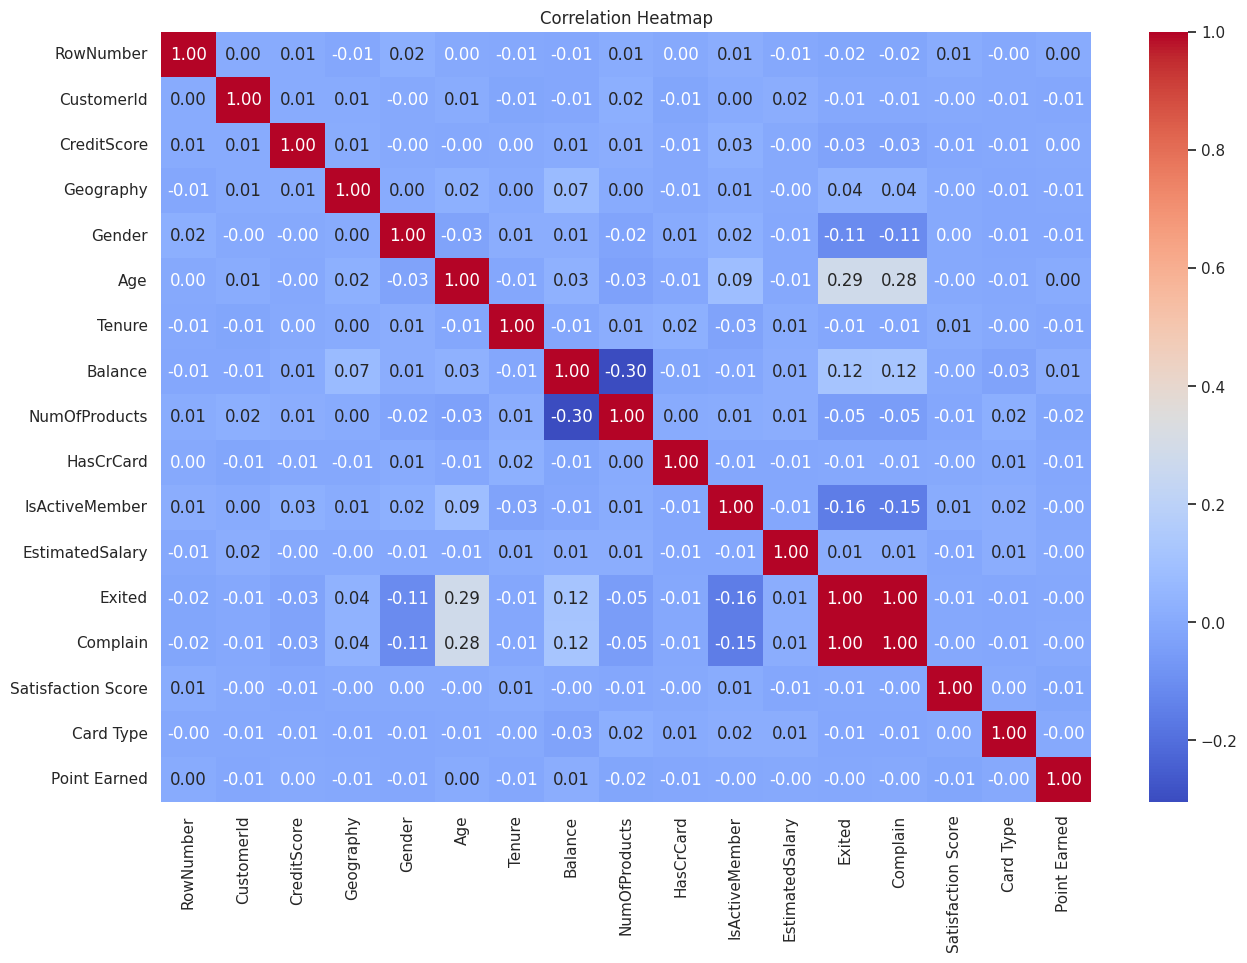

In [ ]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
df = df.drop('Complain', axis=1)
df.head()

,RowNumber,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,1,15634602,619,0,0,42,2,0.00,1,1,1,101348.88,1,2,0,464
1,2,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58,0,3,0,456
2,3,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57,1,3,0,377
3,4,15701354,699,0,0,39,1,0.00,2,0,0,93826.63,0,5,1,350
4,5,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10,0,5,1,425


# Train Test Split

In [ ]:
X = df.drop('Exited', axis=1)
y = df['Exited']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# ML Modelling & Training

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
dtree = DecisionTreeClassifier(class_weight='balanced')
param_grid = {
    'max_depth': [4, 5, 6, 7],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3],
    'random_state': [0, 42]
}

# Perform a grid search with cross-validation to find the best hyperparameters
grid_search = GridSearchCV(dtree, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Print the best hyperparameters
print(grid_search.best_params_)

{'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 2, 'random_state': 0}


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(random_state=0, max_depth=4, min_samples_leaf=1, min_samples_split=2, class_weight='balanced')
dtree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=4, random_state=0)

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = dtree.predict(X_test)
print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100 ,2), "%")

Accuracy Score : 69.3 %


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
print('F-1 Score : ',(f1_score(y_test, y_pred)))
print('Precision Score : ',(precision_score(y_test, y_pred)))
print('Recall Score : ',(recall_score(y_test, y_pred)))

F-1 Score :  0.5119236883942766
Precision Score :  0.37749120750293086
Recall Score :  0.7950617283950617


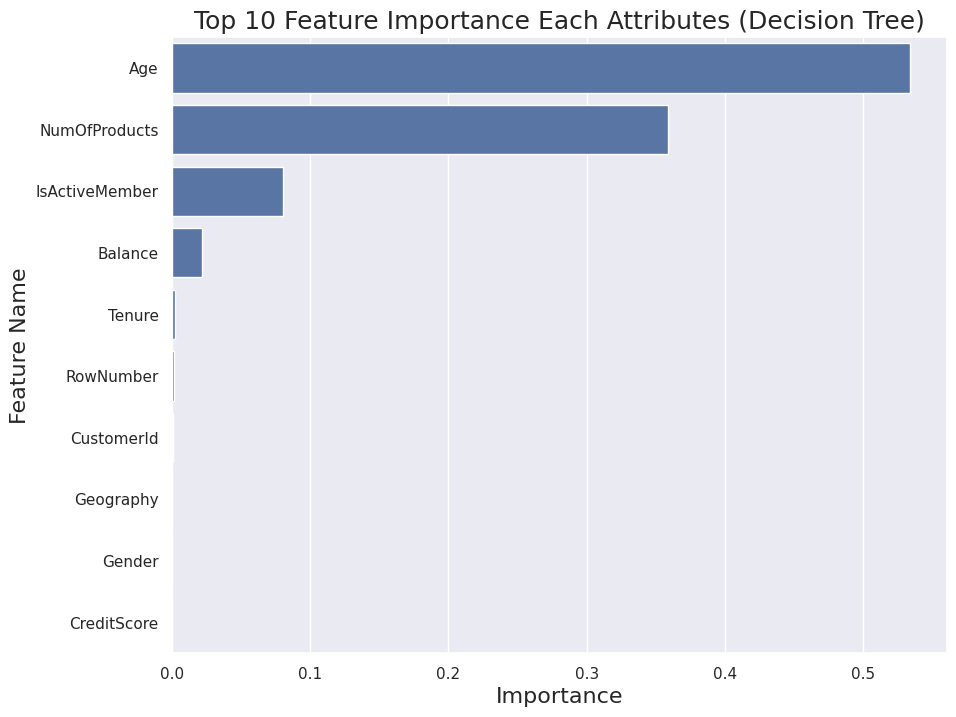

In [ ]:
imp_df = pd.DataFrame({
    "Feature Name": X_train.columns,
    "Importance": dtree.feature_importances_
})
fi = imp_df.sort_values(by="Importance", ascending=False)

fi2 = fi.head(10)
plt.figure(figsize=(10,8))
sns.barplot(data=fi2, x='Importance', y='Feature Name')
plt.title('Top 10 Feature Importance Each Attributes (Decision Tree)', fontsize=18)
plt.xlabel ('Importance', fontsize=16)
plt.ylabel ('Feature Name', fontsize=16)
plt.savefig('feature_importance_dtree.png', format='png', bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'Accuracy Score for Decision Tree: 69.30%')

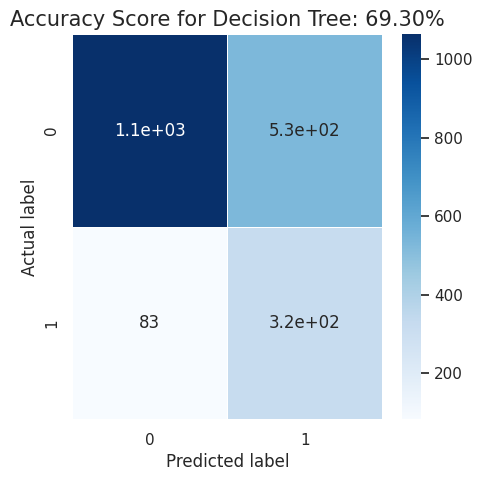

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(data=cm,linewidths=.5, annot=True,  cmap = 'Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score for Decision Tree: {0:.2f}%'.format(dtree.score(X_test, y_test)*100)
plt.title(all_sample_title, size = 15)

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(class_weight='balanced', random_state=0)

# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [6, 8, 10],       # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]     # Minimum number of samples required to be at a leaf node
}

# Perform a grid search with cross-validation to find the best hyperparameters
grid_search_rf = GridSearchCV(rf_classifier, param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)

# Print the best hyperparameters
print("Best hyperparameters for Random Forest:", grid_search_rf.best_params_)

Best hyperparameters for Random Forest: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [19]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier with the best hyperparameters
rf_classifier_tuned = RandomForestClassifier(random_state=0, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=200, class_weight='balanced')

# Train the model
rf_classifier_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, n_estimators=200, random_state=0)

In [20]:
from sklearn.metrics import accuracy_score
y_pred = rf_classifier_tuned.predict(X_test)
print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100 ,2), "%")

Accuracy Score : 83.45 %


In [21]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
print('F-1 Score : ',(f1_score(y_test, y_pred)))
print('Precision Score : ',(precision_score(y_test, y_pred)))
print('Recall Score : ',(recall_score(y_test, y_pred)))

F-1 Score :  0.6199770378874856
Precision Score :  0.5793991416309013
Recall Score :  0.6666666666666666


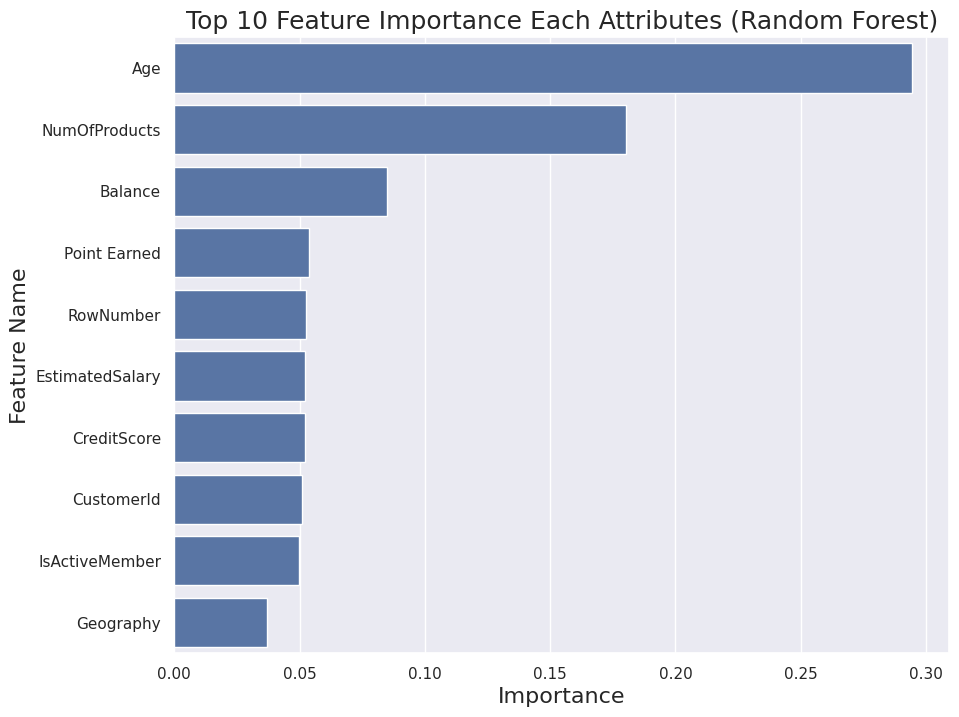

In [22]:
imp_df_rf = pd.DataFrame({
    "Feature Name": X_train.columns,
    "Importance": rf_classifier_tuned.feature_importances_
})
fi_rf = imp_df_rf.sort_values(by="Importance", ascending=False)

fi2_rf = fi_rf.head(10)
plt.figure(figsize=(10,8))
sns.barplot(data=fi2_rf, x='Importance', y='Feature Name')
plt.title('Top 10 Feature Importance Each Attributes (Random Forest)', fontsize=18)
plt.xlabel ('Importance', fontsize=16)
plt.ylabel ('Feature Name', fontsize=16)
plt.savefig('feature_importance_random_forest.png', format='png', bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'Accuracy Score for Random Forest: 83.45%')

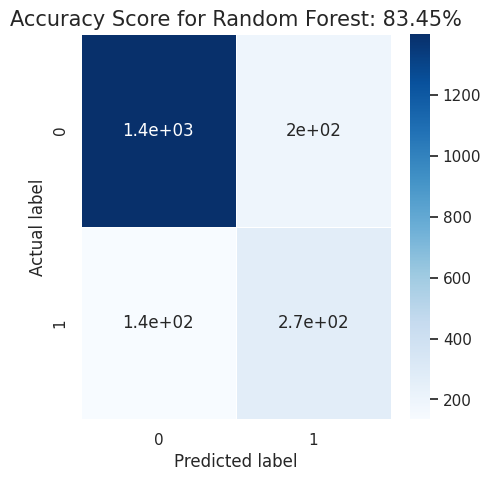

In [23]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(data=cm,linewidths=.5, annot=True,  cmap = 'Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score for Random Forest: {0:.2f}%'.format(rf_classifier_tuned.score(X_test, y_test)*100)
plt.title(all_sample_title, size = 15)

REGRESSION PREDICTION

In [24]:
X = df.drop('Age', axis=1)
y = df['Age']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [25]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# 1) Drop rows where y is NaN, and align X accordingly
mask = ~y_train.isna()
X_train_clean = X_train.loc[mask]
y_train_clean = y_train.loc[mask]


# 2) Set up model + grid
dt_regressor = DecisionTreeRegressor(random_state=0)
param_grid_dt_reg = {
    'max_depth': [4, 5, 6],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3],
}

# 3) Grid search
grid_search_dt_reg = GridSearchCV(
    dt_regressor,
    param_grid_dt_reg,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search_dt_reg.fit(X_train_clean, y_train_clean)

print("Best hyperparameters for Decision Tree Regressor:", grid_search_dt_reg.best_params_)

Best hyperparameters for Decision Tree Regressor: {'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 2}


In [26]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor with the specified hyperparameters
dt_regressor_tuned = DecisionTreeRegressor(random_state=0,
                                           max_depth=6,
                                           min_samples_leaf=1,
                                           min_samples_split=2)

# Train the model
dt_regressor_tuned.fit(X_train_clean, y_train_clean)

DecisionTreeRegressor(max_depth=6, random_state=0)

In [27]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Drop rows where y_test is NaN, and align X_test accordingly
mask_test = ~y_test.isna()
X_test_clean = X_test.loc[mask_test]
y_test_clean = y_test.loc[mask_test]

# Make predictions on the cleaned test set
y_pred_dt_reg = dt_regressor_tuned.predict(X_test_clean)

# Calculate and print regression metrics
print("R2 Score:", r2_score(y_test_clean, y_pred_dt_reg))
print("Mean Squared Error (MSE):", mean_squared_error(y_test_clean, y_pred_dt_reg))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_test_clean, y_pred_dt_reg)))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test_clean, y_pred_dt_reg))

R2 Score: 0.053538233092392584
Mean Squared Error (MSE): 107.05448897527506
Root Mean Squared Error (RMSE): 10.346713921592452
Mean Absolute Error (MAE): 7.563074014276689


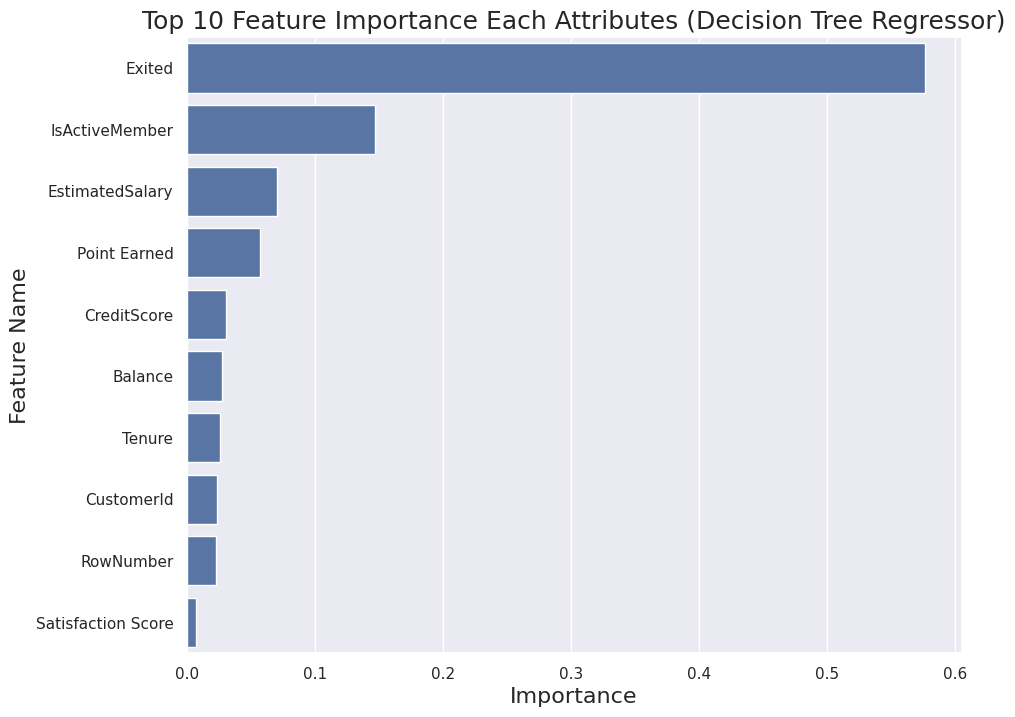

In [28]:
imp_df_dt_reg = pd.DataFrame({
    "Feature Name": X_train_clean.columns,
    "Importance": dt_regressor_tuned.feature_importances_
})
fi_dt_reg = imp_df_dt_reg.sort_values(by="Importance", ascending=False)

fi2_dt_reg = fi_dt_reg.head(10)
plt.figure(figsize=(10,8))
sns.barplot(data=fi2_dt_reg, x='Importance', y='Feature Name')
plt.title('Top 10 Feature Importance Each Attributes (Decision Tree Regressor)', fontsize=18)
plt.xlabel ('Importance', fontsize=16)
plt.ylabel ('Feature Name', fontsize=16)
plt.savefig('feature_importance_dtree_regressor.png', format='png', bbox_inches='tight')
plt.show()